# Radial Eigenfunction Solver and Wavefunction Reconstruction

This notebook computes the radial eigenfunctions $f_{nl}(r)$ for ultralight dark matter (ULDM) solitons and provides tools for initial wavefunction reconstruction.

## Overview

The notebook is divided into two main sections:

### Part I: Eigenfunction Computation (Steps 1–5)
Solve the radial Schrödinger equation with a self-gravitating soliton potential to obtain:
- Radial eigenfunctions $f_{nl}(r)$ for each angular momentum $\ell$ and radial index $n$
- Corresponding eigenvalues $E_{nl}$

### Part II: Wavefunction Reconstruction (Steps 6–9)
Using pre-computed $c_{nlm}(t)$ coefficients, reconstruct 3D wavefunctions:
- Build initial conditions with specified mode compositions
- Apply center-of-mass and velocity corrections (deboosting)
- Validate mode mass fractions

## Mathematical Background

The ULDM wavefunction is expanded as:

$$\psi(\mathbf{r}, t) = \sum_{n,\ell,m} c_{nlm}(t) \, f_{nl}(r) \, Y_\ell^m(\theta, \phi) \, e^{-i E_{nl} t}$$

The radial eigenfunctions satisfy:

$$\left[ -\frac{1}{2} \frac{d^2}{dr^2} + \frac{\ell(\ell+1)}{2r^2} + \Phi(r) \right] u_{nl}(r) = E_{nl} \, u_{nl}(r)$$

where $f_{nl}(r) = u_{nl}(r) / r$ and $\Phi(r)$ is the gravitational potential from the soliton density profile.

## Key Functions Used

| Function | Module | Purpose |
|----------|--------|---------|
| `load_soliton_file()` | `uldm_eig1` | Load dimensionless soliton profile |
| `soliton_density_function()` | `uldm_eig1` | Construct scaled density $\rho(r)$ |
| `compute_potential()` | `uldm_eig1` | Compute gravitational potential $\Phi(r)$ |
| `make_all_eigs()` | `uldm_eig1` | Solve eigenvalue problem for all $\ell$ |
| `save_eigs_to_h5()` | `uldm_eig1` | Save eigenfunctions to HDF5 |
| `build_initial_wavefunction()` | `wavefunction_tools` | Reconstruct 3D wavefunction |
| `deboost_wavefunction()` | `wavefunction_tools` | Apply COM/velocity corrections |
| `compute_mode_fractions()` | `wavefunction_tools` | Validate mode mass contributions |

## Prerequisites

- **Soliton profile**: `soliton.h5` (included in `Eig_ULDM_packages`)
- **For Part II**: `c_nlm_*.h5` file from `compute_c_nlm.ipynb`

---
# Part I: Eigenfunction Computation
---

## Step 1: Import Libraries and Load Soliton Profile

Initialize the Python environment and load the dimensionless soliton profile from the package resources.

**Key actions**:
- Set axion mass via `PYUL_AXION_MASS_EV` environment variable
- Load `soliton.h5` containing the ground-state profile $\psi_0(y)$
- Change to the working directory containing simulation outputs

**Note**: The soliton profile is stored in dimensionless units and will be scaled to the target mass in Step 2.

In [ ]:
# ULDM eigenvalue solver demonstration
#
# This notebook reproduces the workflow of the reference Mathematica notebook `f_nl.nb`
# using the Python implementation provided in `Eig_ULDM_packages/uldm_eig.py`.  We load the
# soliton profile, reconstruct the density and potential, solve the radial
# eigenvalue problem for several angular momentum channels, and compare the
# results to the reference data.

from Eig_ULDM_packages.uldm_eig1 import *
import os
import importlib.resources as resources

# ============================================================================
# USER CONFIGURATION
# ============================================================================
os.environ["PYUL_AXION_MASS_EV"] = "1e-21"  # <-- Set axion mass for your simulation

from Eig_ULDM_packages.units import *
import numpy as np
import matplotlib.pyplot as plt
import scipy

# Load the dimensionless soliton profile (bundled with the package)
soliton_path = resources.files("Eig_ULDM_packages") / "soliton.h5"
sol = load_soliton_file(str(soliton_path))

# Optional: Change to your working directory for saving outputs
# work_dir = "/path/to/your/simulation/Outputs"  # <-- CHANGE THIS if needed
work_dir = None  # Set to None to use current directory
if work_dir:
    os.chdir(work_dir)

# Print library versions for reproducibility
print(f"numpy version: {np.__version__}")
print(f"scipy version: {scipy.__version__}")
print(f"matplotlib version: {plt.matplotlib.__version__}")
try:
    import h5py
    print(f"h5py version: {h5py.__version__}")
except ImportError:
    print("h5py is not installed in this environment.")

numpy version: 1.26.4
scipy version: 1.13.1
matplotlib version: 3.9.3
h5py version: 3.12.1


## Step 2: Define Physical Parameters and Compute Potential

Set the soliton mass and radial domain, then construct the gravitational potential $\Phi(r)$.

**User parameters**:
- `mass_physics`: Soliton mass in solar masses $M_\odot$
- `rmax_physics`: Maximum radius in kpc
- `n_grid`: Number of radial grid points for the finite-difference solver

**Key computations**:
1. Convert physical units to code units via `convert_between()`
2. Build the density function $\rho(r)$ using `soliton_density_function()`
3. Compute potential $\Phi(r)$ via Poisson integration using `compute_potential()`

**Outputs**: Plots of $\rho(r)$ and $\Phi(r)$ for visual verification against expected soliton profiles.

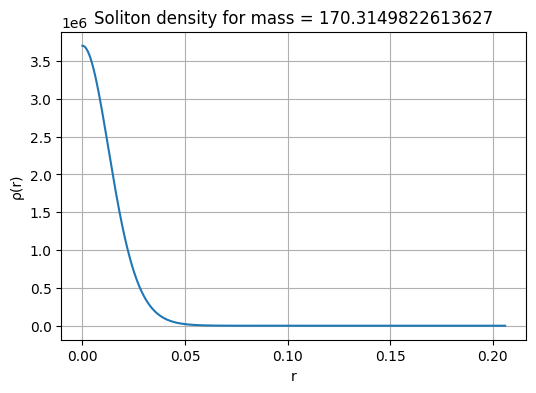

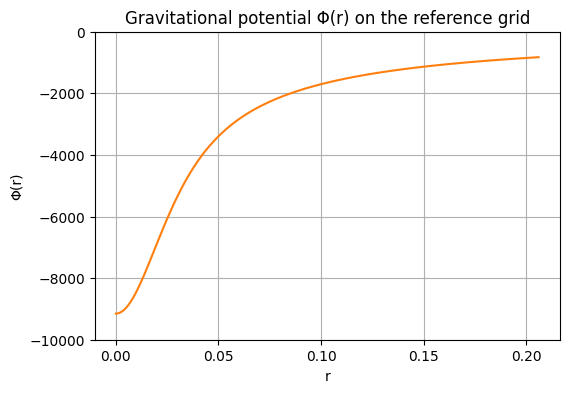

In [2]:
# Parameters matching the reference computation
mass_physics = 12 # M_solar_masses
rmax_physics = 2.5*2/2 # kpc
# Convert to code units
mass = convert_between(mass_physics,'M_solar_masses','','m')
rmax = convert_between(rmax_physics,'kpc','','l')
#mass = 50
n_grid = 5120
#rmax = 0.10302399470847219*2
#rmax = 1

# Construct the uniform radial grid used by the finite difference solver.
# The grid excludes r=0 and spans (dr, 2 dr, ..., rmax) where dr = rmax/n_grid.
dr = rmax / n_grid
rmin=0
r_grid = np.linspace(rmin, rmax, n_grid)

# Build the mass-rescaled density function ρ(r)
rho_func = soliton_density_function(mass, sol)

# Evaluate the density on the grid and compute the gravitational potential Φ(r)
rho_vals = rho_func(r_grid)
phi = compute_potential(r_grid, rho_func)
#phi_grid = compute_potential_from_grid(r_grid,
#                                       potential_path='./3GravRS/G3R_#000.npy',
#                                       com_path=None,
#                                       dx=None,
#                                       assume_centered=True,
#                                       method='spherical_average',
#                                       strict=False,
#                                       subtract_mean=False)
# Plot the density and potential for visual comparison with the reference
plt.figure(figsize=(6, 4))
plt.plot(r_grid, rho_vals, color='tab:blue')
plt.xlabel('r')
plt.ylabel('ρ(r)')
plt.title(f'Soliton density for mass = {mass}')
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(r_grid, phi, color='tab:orange')
plt.ylim(-10000, 0)
plt.xlabel('r')
plt.ylabel('Φ(r)')
plt.title('Gravitational potential Φ(r) on the reference grid')
plt.grid(True)
plt.show()

#plt.figure(figsize=(6, 4))
#plt.plot(r_grid, phi_grid, color='tab:green')
#plt.ylim(-10000, 500)
#plt.xlabel('r')
#plt.ylabel('Φ(r)')
#plt.title('Gravitational potential Φ(r) from grid data')
#plt.grid(True)
#plt.show()


## Step 3: Solve Radial Eigenvalue Problem

Compute the radial eigenfunctions $f_{nl}(r)$ and eigenvalues $E_{nl}$ for angular momenta $\ell = 0, 1, \ldots, \ell_{\max}$.

**Function**: `make_all_eigs(r_grid, phi, lmax, n_eig)`

**Parameters**:
- `lmax`: Maximum angular momentum quantum number
- `n_eig`: Number of eigenvalues/eigenfunctions to compute per $\ell$

**Method**: 
The solver uses a finite-difference discretization of the radial Schrödinger equation with an effective potential:

$$V_{\text{eff}}(r) = \frac{\ell(\ell+1)}{2r^2} + \Phi(r)$$

Sparse matrix eigenvalue routines (ARPACK via SciPy) extract the lowest `n_eig` eigenvalues.

**Output**: Dictionary `eigs_data` with structure `eigs_data['ell/{ℓ}']['E']` (eigenvalues) and `eigs_data['ell/{ℓ}']['f']` (eigenfunctions).

In [3]:
# Solve the radial eigenvalue problem for ℓ = 0 .. lmax
lmax = 10
n_eig = 25

# Compute eigenvalues and eigenfunctions for each ℓ
print(f"Solving eigenvalue problems for ℓ = 0..{lmax} with n_eig = {n_eig}")
eigs_data = make_all_eigs(r_grid, phi, lmax, n_eig, maxiter=2000000)
'''''
# Plot the first few eigenfunctions for each ℓ and print the eigenvalues
for ell in range(lmax + 1):
    key = f'ell/{ell}'
    E = eigs_data[key]['E']
    f_mat = eigs_data[key]['f']
    plt.figure(figsize=(6, 4))
    for n in range(min(5, n_eig)):
        plt.plot(r_grid, f_mat[:, n], label=f'n = {n}')
    plt.xlabel('r')
    plt.ylabel('$f_{n,ℓ}(r)$')
    plt.title(f'Eigenfunctions for ℓ = {ell}')
    plt.legend()
    plt.grid(True)
    plt.show()
    print(f"ℓ = {ell}, eigenvalues E =", E)
'''''

Solving eigenvalue problems for ℓ = 0..10 with n_eig = 25


'\'\'\n# Plot the first few eigenfunctions for each ℓ and print the eigenvalues\nfor ell in range(lmax + 1):\n    key = f\'ell/{ell}\'\n    E = eigs_data[key][\'E\']\n    f_mat = eigs_data[key][\'f\']\n    plt.figure(figsize=(6, 4))\n    for n in range(min(5, n_eig)):\n        plt.plot(r_grid, f_mat[:, n], label=f\'n = {n}\')\n    plt.xlabel(\'r\')\n    plt.ylabel(\'$f_{n,ℓ}(r)$\')\n    plt.title(f\'Eigenfunctions for ℓ = {ell}\')\n    plt.legend()\n    plt.grid(True)\n    plt.show()\n    print(f"ℓ = {ell}, eigenvalues E =", E)\n'

## Step 4: Visualize Eigenfunction Panel

Generate a publication-ready multi-panel figure showing selected eigenfunctions $f_{nl}(r)$.

**Function**: `plot_eigenfunction_panel()` from `Eig_ULDM_packages.fnl_plotting`

**User parameters**:
- `ells`: List of $\ell$ values to display (rows)
- `ns`: List of $n$ values to display (columns)
- `max_plot_points`: Downsampling for efficient vector output

The figure uses consistent styling across panels and is suitable for EPS export.

Saved EPS to: /data/maudlin/alanz/Stone_Skipping/128_0.02_3000_500_doubleBoxsize_2/20251016_113439@128/Outputs/f_nl_grid_3x5.eps
Downsampling: r has 5120 points, plotted with <= 2000 (step=3)


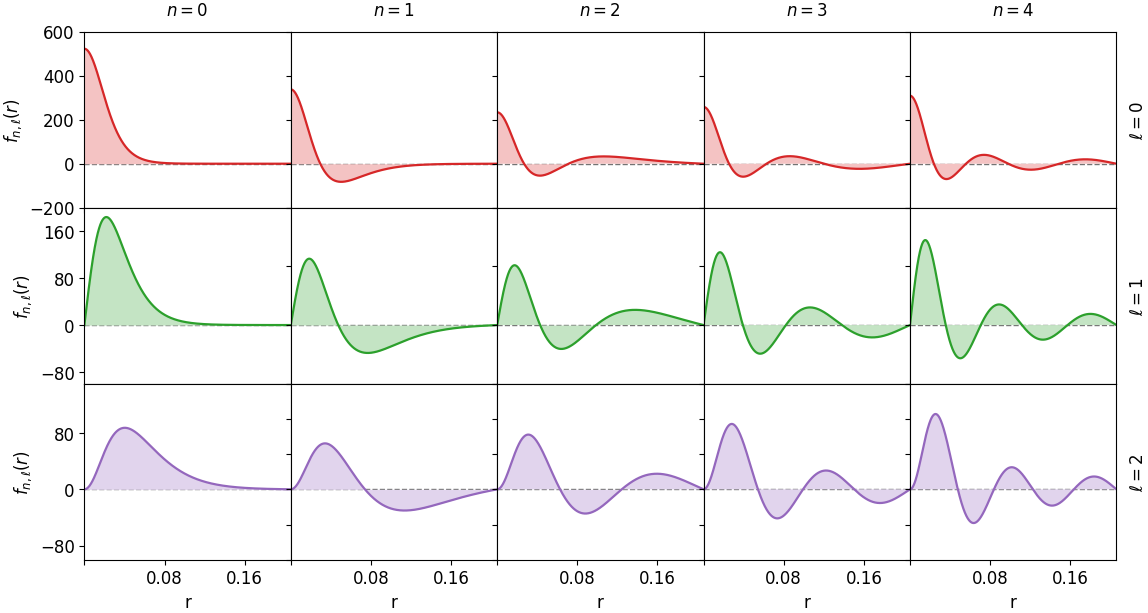

(<Figure size 1200x660 with 15 Axes>,
 array([[<Axes: ylabel='$f_{n,\\ell}(r)$'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='$f_{n,\\ell}(r)$'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: xlabel='r', ylabel='$f_{n,\\ell}(r)$'>,
         <Axes: xlabel='r'>, <Axes: xlabel='r'>, <Axes: xlabel='r'>,
         <Axes: xlabel='r'>]], dtype=object))

In [4]:
from Eig_ULDM_packages.fnl_plotting import plot_eigenfunction_panel

# User controls (edit these)
ells = [0, 1, 2]
ns = [0, 1, 2, 3, 4]
max_plot_points = 2000
width_per_col = 2.4
height_per_row = 2.2

plot_eigenfunction_panel(
    r_grid,
    eigs_data,
    ells=ells,
    ns=ns,
    max_plot_points=max_plot_points,
    width_per_col=width_per_col,
    height_per_row=height_per_row,
)

## Step 5: Save Eigenfunctions to HDF5

Persist the computed eigenvalues and eigenfunctions for use in downstream analysis (particularly `compute_c_nlm.ipynb`).

**Function**: `save_eigs_to_h5(eigs_data, filename)`

**Output file structure**:
```
eigs_*.h5
├── r_grid          # Radial grid array
├── ell/0/E         # Eigenvalues for ℓ=0
├── ell/0/f         # Eigenfunctions for ℓ=0 (shape: n_grid × n_eig)
├── ell/1/E
├── ell/1/f
└── ...
```

**⚠️ Important**: After this step, proceed to `compute_c_nlm.ipynb` to compute $c_{nlm}(t)$ coefficients. Return here for Part II (Steps 6–9) after generating the $c_{nlm}$ file.

In [5]:
# Persist the computed eigenpairs to an HDF5 file
save_eigs_to_h5(eigs_data, 'eigs_mass_170_Eig_25_lmax_10_nig_5120_py2.h5')

---
# Part II: Wavefunction Reconstruction
---

This section builds 3D initial wavefunctions from the eigenmode expansion. It requires:
- Eigenfunctions from Part I (Steps 1–5)
- $c_{nlm}(t)$ coefficients from `compute_c_nlm.ipynb`

The reconstructed wavefunctions are compatible with PyUL_SK for controlled numerical experiments.

## Step 6: Load $c_{nlm}$ and Prepare Mode Amplitudes

Load time-dependent coefficients from the HDF5 file and extract mode amplitudes $\epsilon_{nlm}$ at a specific time point.

**Function**: `prepare_epsilon_nlm()` from `Eig_ULDM_packages.cnlm_postprocess`

**User parameters**:
- `c_out_file`: Path to the $c_{nlm}(t)$ HDF5 file
- `t_point`: Time index to extract coefficients from
- `nlm_list`: List of $(n, \ell, m)$ modes to include
- `use_file_eps`: If `True`, read from file; if `False`, use manual values

**Outputs**:
- `epsilon_nlm_list`: Complex amplitudes for each mode
- Normalization check: $\sum |c_{nlm}|^2 \approx M$ (soliton mass)

**Note**: The amplitudes are normalized such that $|c_{000}|^2 / M = 1$ for a pure ground-state soliton.

In [6]:
from Eig_ULDM_packages.c_nlm_integrator import load_cnlm_from_h5
from Eig_ULDM_packages.cnlm_postprocess import prepare_epsilon_nlm

c_out_file = 'c_nlm_mass170.h5'
t_file, c_file, attrs_file = load_cnlm_from_h5(c_out_file)
t_point = 416

resol = 128
length, length_units = 2.5 * 2, 'kpc'
mS, s_mass_unit = 12, 'M_solar_masses'
s_velocity_unit = 'km/s'
CellCenteredGrid = True
mS_code_unit = convert_between(mS, s_mass_unit, '', 'm')

nlm_list = [(0, 0, 0), (0, 1, 0), (0, 1, -1), (0, 1, 1),
            (1, 1, 0), (1, 1, -1), (1, 1, 1)]

use_file_eps = True  # True: read from c_nlm file; False: use manual epsilon list
manual_epsilon_nlm_list = None  # set to a list of complex values when use_file_eps is False

epsilon_nlm_list, coeffs, check = prepare_epsilon_nlm(
    nlm_list,
    use_file=use_file_eps,
    c_file=c_file,
    t_point=t_point,
    mass=mass,
    epsilon_nlm_list=manual_epsilon_nlm_list,
    normalize_c000=True,
    print_coeffs=True,
    print_norm=True,
    inject_globals=globals(),
)

center_of_mass = [0, 0, 0]
COM_speed = [0, 0, 0]
Phase = 0
solitons = [[mS_code_unit, center_of_mass, COM_speed, Phase * np.pi]]
start_time, duration_units = 0, 'Myr'
init_basename = 'Soliton_plus_n_1_ell_1_Init_128'

c_{000}=(-0.9422917814747174+0.3297166318596766j)
c_{010}=(-8.38763390302727e-06-2.6892042306564403e-06j)
c_{01-1}=(0.0009859583489713498+0.0023237379550124174j)
c_{011}=(-0.0019297615578367882+0.0030954304099148405j)
c_{110}=(-7.996793475680026e-06+1.7906129019358714e-06j)
c_{11-1}=(-0.04134940280727233-0.040517690782847074j)
c_{111}=(-0.001324842422943415-0.0005019643353873207j)
|c_{000}|^2=0.9966268587596863
|c_{010}|^2=7.758422188539294e-11
|c_{01-1}|^2=6.371871949471602e-06
|c_{011}|^2=1.3305669092730227e-05
|c_{110}|^2=6.715500045725784e-11
|c_{11-1}|^2=0.003351456378892472
|c_{111}|^2=2.007175639631413e-06
Check normalization: 0.9999999999999998


## Step 7: Build Initial 3D Wavefunction

Reconstruct the 3D wavefunction on a Cartesian grid from the eigenmode expansion:

$$\psi(\mathbf{r}) = \sum_{n,\ell,m} \epsilon_{nlm} \, f_{nl}(r) \, Y_\ell^m(\theta, \phi) \, e^{i\phi_0}$$

**Function**: `build_initial_wavefunction()` from `Eig_ULDM_packages.wavefunction_tools`

**User parameters**:
- `resol`: Grid resolution (cells per axis)
- `length`, `length_units`: Box size in physical units
- `center_of_mass`, `COM_speed`: Target COM position and velocity
- `Phase`: Global phase factor (in units of $\pi$)
- `nprocs`: Number of parallel workers

**Outputs**:
- `Psi`: 3D complex wavefunction array
- `psi_path`: Path to saved `.npy` file
- Diagnostic: Total mass, per-mode masses, measured COM

The output is compatible with PyUL `InitPath` format.

In [13]:
import importlib
import Eig_ULDM_packages.wavefunction_tools as wf_tools
importlib.reload(wf_tools)
build_initial_wavefunction = wf_tools.build_initial_wavefunction

nprocs = 12  # change as needed; 8 is a safe default cap

result = build_initial_wavefunction(
    eigs_data=eigs_data,
    r_grid=r_grid,
    length=length,
    length_units=length_units,
    resol=resol,
    CellCenteredGrid=CellCenteredGrid,
    mS_code_unit=mS_code_unit,
    s_velocity_unit=s_velocity_unit,
    nlm_list=nlm_list,
    epsilon_nlm_list=epsilon_nlm_list,
    center_of_mass=center_of_mass,
    COM_speed=COM_speed,
    Phase=Phase,
    start_time=start_time,
    duration_units=duration_units if 'duration_units' in globals() else None,
    init_basename=init_basename,
    nprocs=nprocs,
 )

Psi = result["Psi"]
psi_path = result["psi_path"]
COM_meas = result["COM_meas"]
M_tot = result["M_tot"]
mode_masses = result["mode_masses"]
total_modes_mass = result["total_modes_mass"]

Building Psi [pyshtools]: 100%|██████████| 128/128 [00:22<00:00,  5.59slice/s]


Initial wavefunction generated.
  Backend for Y_lm: pyshtools
  Grid: resol=128, CellCenteredGrid=True, dx=0.0032195 (code units)
  COM target (code units): [0. 0. 0.]
  Measured COM (code units): [1.50521008e-05 6.85996377e-05 2.54502634e-07]
  Total mass from |Psi|^2: 1.703151e+02 (code units)
  Per-mode mass contributions (code units) from non-zero epsilon modes:
    (n=0, l=0, m=0) -> 1.697406e+02
    (n=0, l=1, m=0) -> 1.321375e-08
    (n=0, l=1, m=-1) -> 1.085225e-03
    (n=0, l=1, m=1) -> 2.266155e-03
    (n=1, l=1, m=0) -> 1.143750e-08
    (n=1, l=1, m=-1) -> 5.708031e-01
    (n=1, l=1, m=1) -> 3.418520e-04
  Sum of per-mode masses (ignores interference): 1.703151e+02 (code units)
  Interference mass (difference): 6.930435e-09 (code units)
  Saved: /data/maudlin/alanz/Stone_Skipping/128_0.02_3000_500_doubleBoxsize_2/20251016_113439@128/Outputs/Soliton_plus_n_1_ell_1_Init_128_psi.npy
Use this as InitPath in PyUL: 
  InitPath = '/data/maudlin/alanz/Stone_Skipping/128_0.02_3000_50

## Step 8: Deboost Wavefunction to Target COM and Velocity

Iteratively adjust the wavefunction so its center of mass and bulk velocity match the specified targets. This corrects for numerical discretization errors in the initial construction.

**Function**: `deboost_wavefunction()` from `Eig_ULDM_packages.wavefunction_tools`

**Method**:
1. Compute current COM and velocity via density-weighted moments
2. Apply spatial translation: $\psi(\mathbf{r}) \to \psi(\mathbf{r} - \Delta\mathbf{r})$
3. Apply phase gradient (Galilean boost): $\psi \to \psi \, e^{i \mathbf{v} \cdot \mathbf{r}}$
4. Iterate until convergence

**User parameters**:
- `tol_kms`: Velocity convergence tolerance (km/s)
- `tol_pos_frac_dx`: Position tolerance as fraction of grid spacing
- `max_iters`: Maximum iteration count

**Output**: Deboosted wavefunction saved to `*_deboosted.npy` with updated `InitPath` file.

In [14]:
from Eig_ULDM_packages.wavefunction_tools import deboost_wavefunction

IsoP_like = True  # True: isolated differences & spatial shift; False: periodic
fd_order = 4
use_mask = True
mask_mode = 'mass_fraction'
mask_fraction = 1
density_frac = 1e-6
max_iters = 20
tol_kms = 1e-20
tol_pos_frac_dx = 0.05

deboost_result = deboost_wavefunction(
    init_basename=init_basename,
    resol=resol,
    length=length,
    length_units=length_units,
    CellCenteredGrid=CellCenteredGrid,
    center_of_mass=center_of_mass,
    COM_speed=COM_speed,
    s_velocity_unit=s_velocity_unit,
    IsoP_like=IsoP_like,
    fd_order=fd_order,
    use_mask=use_mask,
    mask_mode=mask_mode,
    mask_fraction=mask_fraction,
    density_frac=density_frac,
    max_iters=max_iters,
    tol_kms=tol_kms,
    tol_pos_frac_dx=tol_pos_frac_dx,
    psi_path=psi_path if 'psi_path' in globals() else None,
)

deb_initpath = deboost_result["deb_initpath"]
deb_psipath = deboost_result["deb_psipath"]
psi_path = deboost_result["psi_path"]

[Targeting] Input file: /data/maudlin/alanz/Stone_Skipping/128_0.02_3000_500_doubleBoxsize_2/20251016_113439@128/Outputs/Soliton_plus_n_1_ell_1_Init_128_psi.npy
  Grid: N=128, dx=3.219500e-03 (code length units)
  Targets (code units): COM=[0.0, 0.0, 0.0], v=[0.0, 0.0, 0.0]
  Tolerances: |v - v_tgt| < 1.000e-20 km/s, |COM - COM_tgt| < 1.610e-04 (code length units)
[Targeting] Region mask: mass-fraction, fraction=1.000000, r_cut=2.060867e-01 (code length units).
  Iter 1: v=[8.773998868e-02, -6.492778682e-02, 5.304236398e-05] km/s; COM=[1.5052100804497497e-05, 6.859963766327644e-05, 2.545026341354263e-07] (code)
[Targeting] Region mask: mass-fraction, fraction=1.000000, r_cut=2.062680e-01 (code length units).
  Iter 2: v=[5.946613249e-06, -4.400104562e-06, 3.593521161e-09] km/s; COM=[1.6810470525693232e-10, 7.809084723014505e-10, 2.9328741495275686e-12] (code)
[Targeting] Region mask: mass-fraction, fraction=1.000000, r_cut=2.062680e-01 (code length units).
  Iter 3: v=[4.028770408e-10,

## Step 9: Validate Mode Mass Fractions

Project the reconstructed wavefunction back onto the $(n, \ell, m)$ basis to verify mode composition.

**Function**: `compute_mode_fractions()` from `Eig_ULDM_packages.wavefunction_tools`

**Method**:
For each mode $(n, \ell, m)$, compute the overlap integral:

$$M_{nlm} = \left| \int \psi^*(\mathbf{r}) \, f_{nl}(r) \, Y_\ell^m(\theta, \phi) \, d^3r \right|^2$$

**Output**: Report showing:
- Per-mode mass fractions $M_{nlm} / M_{\text{tot}}$
- Residual mass not captured by listed modes
- Comparison with input $|\epsilon_{nlm}|^2$ values

This validates that the reconstruction faithfully represents the intended mode composition.

In [15]:
from Eig_ULDM_packages.wavefunction_tools import compute_mode_fractions

only_nonzero_eps = False
nprocs_modes = 8

mode_result = compute_mode_fractions(
    eigs_data=eigs_data,
    r_grid=r_grid,
    length=length,
    length_units=length_units,
    resol=resol,
    CellCenteredGrid=CellCenteredGrid,
    nlm_list=nlm_list,
    center_of_mass=center_of_mass,
    epsilon_nlm_list=epsilon_nlm_list,
    only_nonzero_eps=only_nonzero_eps,
    deb_psipath=deb_psipath if 'deb_psipath' in globals() else None,
    deb_initpath=deb_initpath if 'deb_initpath' in globals() else None,
    init_basename=init_basename if 'init_basename' in globals() else None,
    psi_path=psi_path if 'psi_path' in globals() else None,
    nprocs_modes=nprocs_modes,
)

[Mode fractions] Using Psi file: /data/maudlin/alanz/Stone_Skipping/128_0.02_3000_500_doubleBoxsize_2/20251016_113439@128/Outputs/Soliton_plus_n_1_ell_1_Init_128_deboost_psi.npy
[Mode fractions] Y_lm backend: pyshtools
[Mode fractions] Total mass from |Psi|^2 = 1.703151e+02 (code units)

[Mode fractions] Per-mode results:


  (n=0, l=0, m=0) mass=1.697501e+02, frac=9.966831e+01%


  (n=0, l=1, m=-1) mass=2.132679e-02, frac=1.252196e-02%


  (n=0, l=1, m=0) mass=7.800059e-11, frac=4.579782e-11%


  (n=0, l=1, m=1) mass=1.194021e-03, frac=7.010659e-04%


  (n=1, l=1, m=-1) mass=5.407575e-01, frac=3.175043e-01%


  (n=1, l=1, m=0) mass=6.425711e-09, frac=3.772838e-09%


  (n=1, l=1, m=1) mass=4.005958e-04, frac=2.352087e-04%
[Mode fractions] Sum of listed mode masses = 1.703138e+02 (fraction=9.999928e+01%)
[Mode fractions] Unaccounted mass = 1.233497e-03 (code units)
